# **OBJECT DETECTION**

Metode yang digunakan

1.   Template Matching
2.   Edge Detection
3.   Corner  Detection
4.   Grid  Detection
5.   Contour  Detection


In [1]:
#import library
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

TEMPLATE MATHCHING

- Image = citra input
- templ = template yang dicari, uk tidak blh lebh besar dr Image
- method = metode dari templet maching

Jenis-jenis metode
1. TM_SQDIFF
2. TM_SQDIFF_NORMED
3. TM_CCORR
4. TM_CCORR_NORMED
5. TM_CCOEFF
6. TM_CCOEFF_NORMED

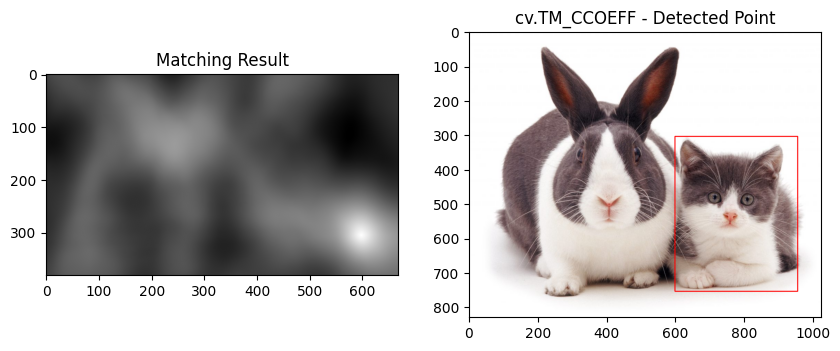

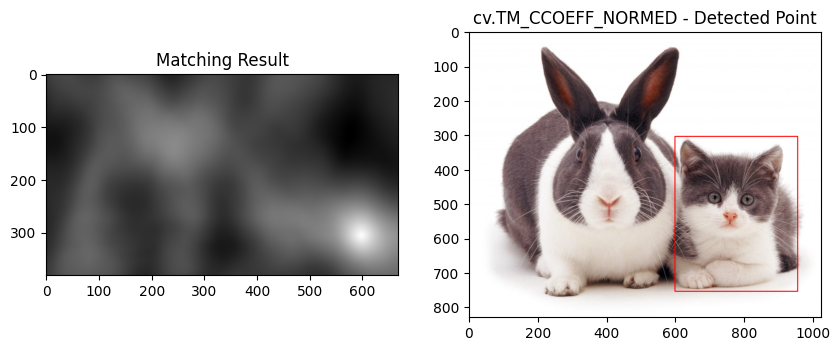

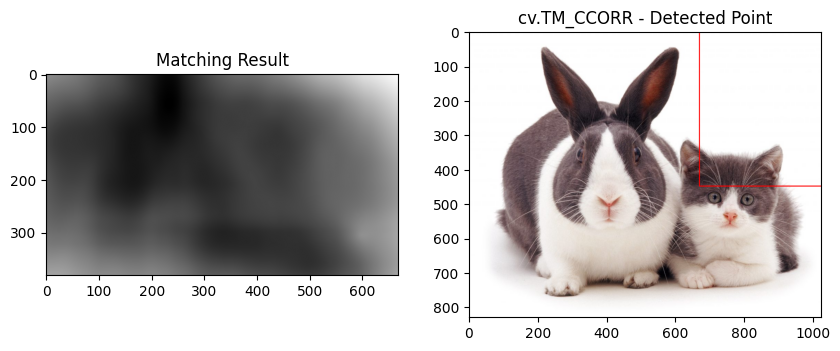

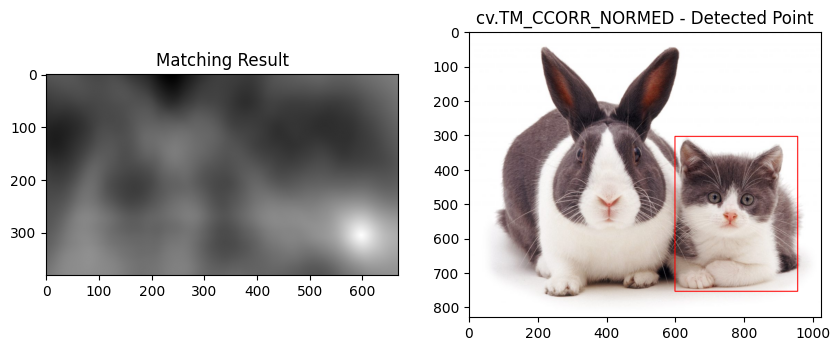

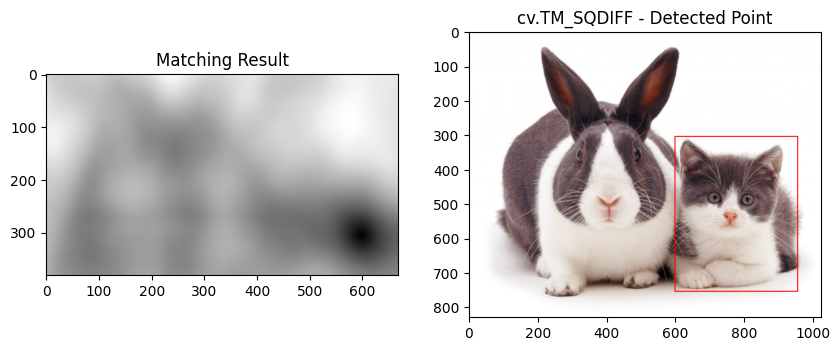

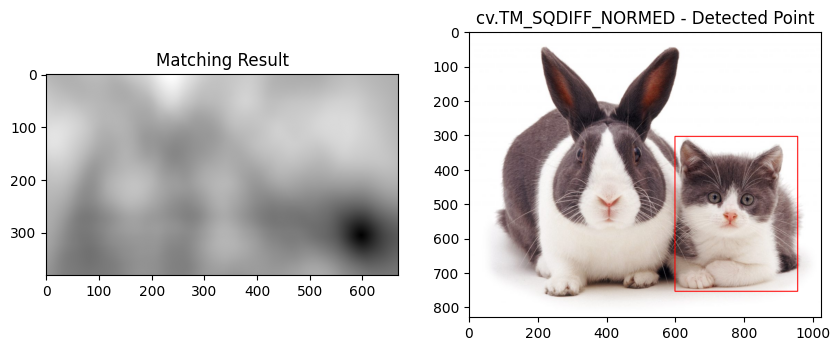

In [2]:
catbuncol = cv.imread('/content/drive/MyDrive/citrapcvk/Object Detection/cats_and_bunnies.jpg')
catbun = cv.cvtColor(catbuncol, cv.COLOR_BGR2GRAY)
cat2 = cv.imread('/content/drive/MyDrive/citrapcvk/Object Detection/cat2_templatejpg.jpg',0)

w,h = cat2.shape[::-1]

methods = ['cv.TM_CCOEFF', 'cv.TM_CCOEFF_NORMED', 'cv.TM_CCORR',
            'cv.TM_CCORR_NORMED', 'cv.TM_SQDIFF', 'cv.TM_SQDIFF_NORMED']

for meth in methods:
    img2 = catbun.copy()
    method = eval(meth)

    # Matching
    res = cv.matchTemplate(img2, cat2, method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    # Tentukan posisi kotak
    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    bottom_right = (top_left[0] + w, top_left[1] + h)

    # Gambar kotak pada versi berwarna
    detected = catbuncol.copy()
    cv.rectangle(detected, top_left, bottom_right, (0, 0, 255), 2)

    # Tampilkan hasil berdampingan
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(res, cmap='gray')
    plt.title('Matching Result')

    plt.subplot(1,2,2)
    plt.imshow(cv.cvtColor(detected, cv.COLOR_BGR2RGB))
    plt.title(f'{meth} - Detected Point')

    plt.show()

3. Implementasikan konsep template matching tanpa menggunakan library OpenCV
untuk multiple object, menggunakan gambar bahrain.jpg untuk citra masukan dan
bahrain-template.jpg sebagai citra template, sehingga menghasilkan output
sebagai berikut:

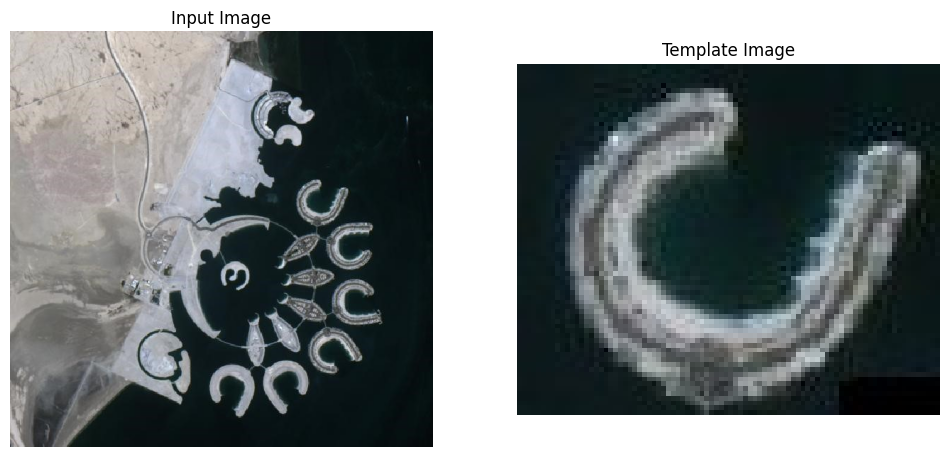

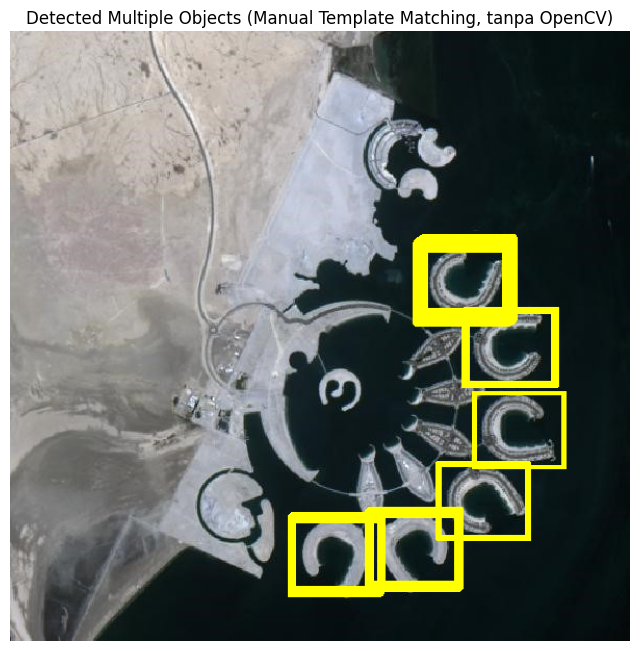

In [3]:
from PIL import Image, ImageDraw
from scipy.signal import correlate2d

img_path = '/content/drive/MyDrive/citrapcvk/Object Detection/bahrain.jpg'
template_path = '/content/drive/MyDrive/citrapcvk/Object Detection/bahrain-template.jpg'

# Baca gambar dan ubah ke RGB
img_rgb = Image.open(img_path).convert('RGB')
template_rgb = Image.open(template_path).convert('RGB')

# Konversi ke grayscale (tanpa OpenCV)
img_gray = np.array(img_rgb.convert('L'), dtype=np.float32)
template_gray = np.array(template_rgb.convert('L'), dtype=np.float32)

# Ukuran template
th, tw = template_gray.shape

# Hitung normalized cross correlation secara manual (pakai SciPy, bukan OpenCV)
template_mean = template_gray - np.mean(template_gray)
res = correlate2d(img_gray, template_mean, mode='valid')

# Normalisasi hasil korelasi agar skala 0–1
res_norm = (res - np.min(res)) / (np.max(res) - np.min(res))

# Tentukan threshold deteksi (semakin kecil = semakin sensitif)
threshold = 0.69
y_coords, x_coords = np.where(res_norm >= threshold)

# Gambar rectangle hasil deteksi (kuning)
img_result = img_rgb.copy()
draw = ImageDraw.Draw(img_result)
for (x, y) in zip(x_coords, y_coords):
    draw.rectangle([x, y, x + tw, y + th], outline="yellow", width=3)

# Tampilkan hasil
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(template_rgb)
plt.title('Template Image')
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(img_result)
plt.title('Detected Multiple Objects (Manual Template Matching, tanpa OpenCV)')
plt.axis('off')
plt.show()

Implementasikan metode Sobel Edge Detection, Canny Edge
Detection, dan Laplacian Edge Detection pada OpenCV dengan
menggunakan gambar car-park.jpg, sehingga menghasilkan luaran
sebagai berikut:


In [4]:
car = ('/content/drive/MyDrive/citrapcvk/Object Detection/car-park.jpg')


a. Sobel Edge Detection

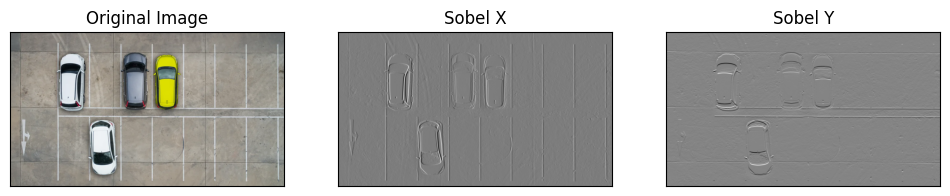

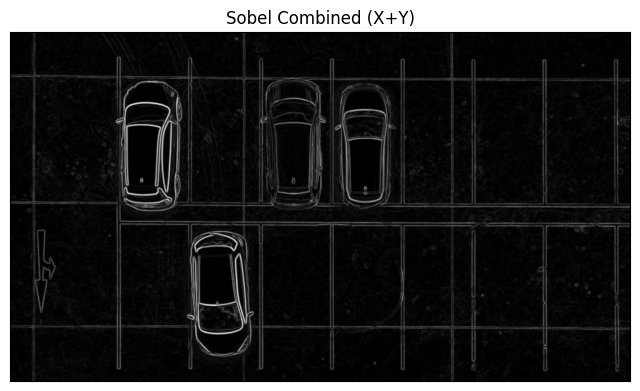

In [5]:
img_color = cv.imread(car)
img = cv.imread(car, cv.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Could not load image.")
else:
    # Sobel X
    sobelx = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=5)
    # Sobel Y
    sobely = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=5)

    # Combine X and Y gradients
    # sobel_combined = cv.addWeighted(sobelx, 0.5, sobely, 0.5, 0)
    sobel_combined = np.sqrt(sobelx**2 + sobely**2)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1), plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
    plt.title('Original Image'), plt.xticks([]), plt.yticks([])
    plt.subplot(1, 3, 2), plt.imshow(sobelx, cmap='gray')
    plt.title('Sobel X'), plt.xticks([]), plt.yticks([])
    plt.subplot(1, 3, 3), plt.imshow(sobely, cmap='gray')
    plt.title('Sobel Y'), plt.xticks([]), plt.yticks([])
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.imshow(sobel_combined, cmap='gray')
    plt.title('Sobel Combined (X+Y)'), plt.xticks([]), plt.yticks([])
    plt.show()

b. Canny Edge Detection

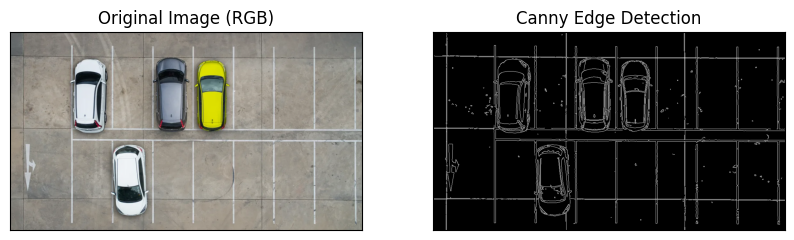

In [6]:
# Convert to grayscale for Canny
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

# Canny Edge Detection
canny = cv.Canny(img_gray, 100, 200) # You can adjust the thresholds (100, 200) as needed

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
plt.title('Original Image (RGB)'), plt.xticks([]), plt.yticks([])
plt.subplot(1, 2, 2), plt.imshow(canny, cmap='gray')
plt.title('Canny Edge Detection'), plt.xticks([]), plt.yticks([])
plt.show()

c. Laplacian Edge Detection

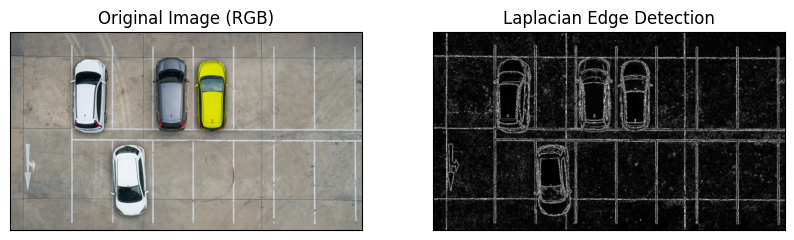

In [7]:
# Convert to grayscale
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

# Laplacian Edge Detection
# Use cv.CV_64F for ddepth to handle negative gradients, and a suitable ksize (e.g., 3)
laplacian = cv.Laplacian(img_gray, cv.CV_64F, ksize=3)

# Scale and convert back to 8-bit unsigned integer for display
laplacian = np.uint8(np.absolute(laplacian))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
plt.title('Original Image (RGB)'), plt.xticks([]), plt.yticks([])
plt.subplot(1, 2, 2), plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian Edge Detection'), plt.xticks([]), plt.yticks([])
plt.show()

5. Implementasikan metode Harris Corner Detection dan Shi-Tomasi
Detection pada OpenCV dengan menggunakan gambar chessboard.jpg, sehingga menghasilkan luaran sebagai berikut:


In [8]:
catur = ('/content/drive/MyDrive/citrapcvk/Object Detection/chess-board.jpg')

a. Harris Corner Detect

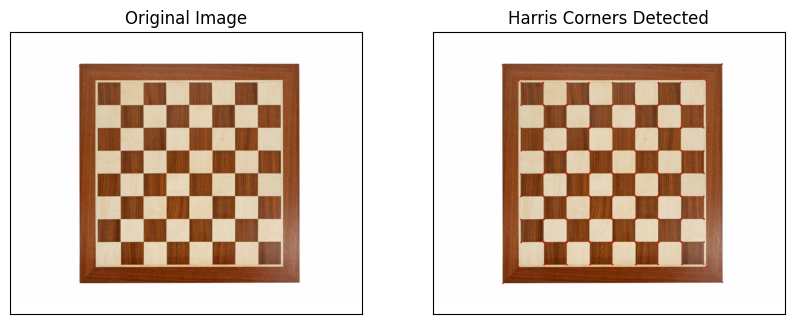

In [9]:
img = cv.imread(catur)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Convert to float32 for cornerHarris
img_gray = np.float32(img_gray)

# Apply Harris Corner Detector
# blockSize: size of neighborhood considered for corner detection
# ksize: aperture parameter of Sobel derivative used
# k: Harris detector free parameter in the equation
dst = cv.cornerHarris(img_gray, 2, 3, 0.04)

# Result is dilated for marking the corners, not important
dst = cv.dilate(dst, None)

# Threshold for an optimal value, it may vary depending on the image.
img_copy = img.copy()
img_copy[dst > 0.01 * dst.max()] = [0, 0, 255] # Mark corners in red

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(1, 2, 2), plt.imshow(cv.cvtColor(img_copy, cv.COLOR_BGR2RGB))
plt.title('Harris Corners Detected'), plt.xticks([]), plt.yticks([])
plt.show()

b. Shi-Tomasi Detection


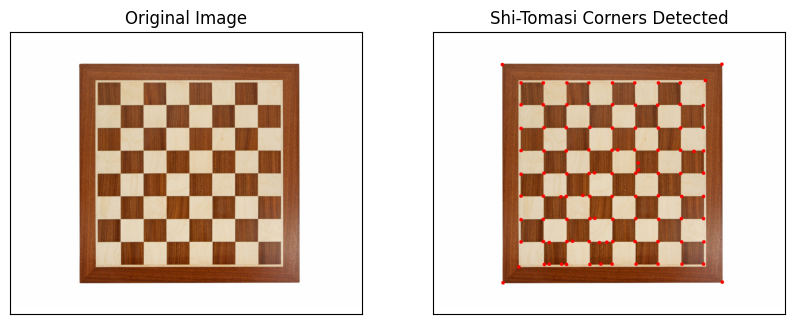

In [10]:
img = cv.imread(catur)

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Shi-Tomasi Corner Detector
# maxCorners: Maximum number of corners to return.
# qualityLevel: Parameter characterizing the minimal accepted quality of image corners.
# minDistance: Minimum possible Euclidean distance between the returned corners.
corners = cv.goodFeaturesToTrack(img_gray, maxCorners=100, qualityLevel=0.01, minDistance=10)
corners = corners.astype(np.int32) # Corrected: use astype(np.int32) instead of np.int0

img_copy = img.copy()
for i in corners:
    x, y = i.ravel()
    cv.circle(img_copy, (x, y), 5, [0, 0, 255], -1) # Draw circles in red

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(1, 2, 2), plt.imshow(cv.cvtColor(img_copy, cv.COLOR_BGR2RGB))
plt.title('Shi-Tomasi Corners Detected'), plt.xticks([]), plt.yticks([])
plt.show()

6. Implementasikan metode Hough Transform pada OpenCV dengan
menggunakan gambar sudoku.jpg. Tahapan proses grid detection sesuai yang
terdapat pada ulasan teori, sehingga menghasilkan luaran sebagai berikut:


In [11]:
sudoku = ('/content/drive/MyDrive/citrapcvk/Object Detection/sudoku.jpg')

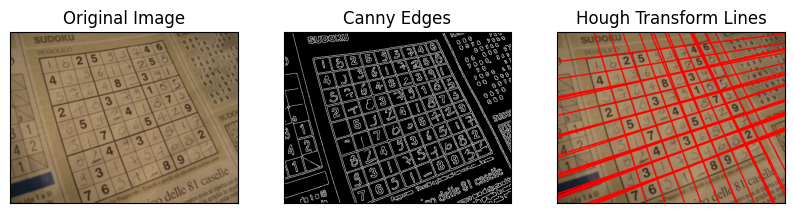

In [12]:
img = cv.imread(sudoku)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply Canny edge detection
edges = cv.Canny(img_gray, 50, 150, apertureSize=3)

# Apply Hough Line Transform (Probabilistic Hough Line Transform is often better for this)
lines = cv.HoughLines(edges, 1, np.pi/180, 163)

# To make it more robust, let's use HoughLinesP (Probabilistic Hough Line Transform)
# lines = cv.HoughLinesP(edges, 1, np.pi/180, threshold=100, minLineLength=100, maxLineGap=10)

# Create a copy of the original image to draw lines on
img_lines = img.copy()

# houghgapakePPP
if lines is not None:
  for line in lines:
      rho, theta = line[0]
      # Konversi (rho, theta) ke koordinat kartesian
      a = np.cos(theta)
      b = np.sin(theta)
      x0 = a * rho
      y0 = b * rho
      x1 = int(x0 + 1000 * (-b))
      y1 = int(y0 + 1000 * (a))
      x2 = int(x0 - 1000 * (-b))
      y2 = int(y0 - 1000 * (a))
      cv.line(img_lines, (x1, y1), (x2, y2), (0, 0, 255), 2)

# if lines is not None:
#     for line in lines:
#         x1, y1, x2, y2 = line[0]
#         cv.line(img_lines, (x1, y1), (x2, y2), (0, 0, 255), 2) #bgr

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1), plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(1, 3, 2), plt.imshow(edges, cmap='gray')
plt.title('Canny Edges'), plt.xticks([]), plt.yticks([])
plt.subplot(1, 3, 3), plt.imshow(cv.cvtColor(img_lines, cv.COLOR_BGR2RGB))
plt.title('Hough Transform Lines'), plt.xticks([]), plt.yticks([])
plt.show()

7. Implementasikan fungsi findContours() pada OpenCV untuk contour detection
dengan menggunakan gambar laptop.jpg, sehingga menghasilkan luaran
sebagai berikut:

In [13]:
laptop = ('/content/drive/MyDrive/citrapcvk/Object Detection/laptop.jpg')

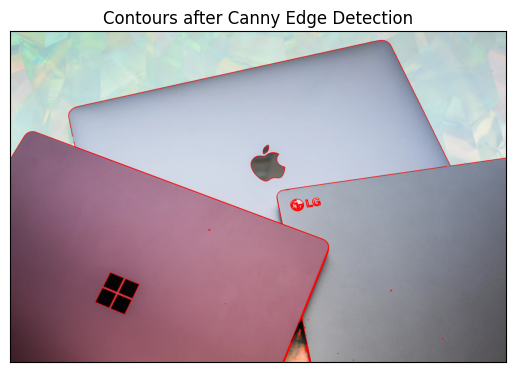

In [14]:
img = cv.imread(laptop) # Load the image first
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply Canny edge detection instead of thresholding
edges = cv.Canny(img_gray, 60, 180) # Adjust thresholds as needed

contours, hierarchy = cv.findContours(edges, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Draw contours on a copy of the original image
img_with_contours = img.copy()
cv.drawContours(img_with_contours, contours, -1, (0,0,255), 3)

plt.imshow(cv.cvtColor(img_with_contours, cv.COLOR_BGR2RGB))
plt.title('Contours after Canny Edge Detection')
plt.xticks([]), plt.yticks([])
plt.show()

# **D2. Praktikum Feature Matching dan Face Detection**

1. Lakukan Face Detection untuk image object lain yang tersedia pada
(/images/facedet). Tampilkan seperti pada contoh berikut.

In [15]:
prabs = ('/content/drive/MyDrive/Images/prabowo.jpg')
kartini = ('/content/drive/MyDrive/Images/facedet/kartini.jpg')
kucing = ('/content/drive/MyDrive/Images/facedet/kucing.jpg')
mask = ('/content/drive/MyDrive/Images/facedet/mask.jpg')
jordan = ('/content/drive/MyDrive/Images/facedet/mjordan.jpg')
solva = ('/content/drive/MyDrive/Images/facedet/solvayconf.jpg')



## ORB Feature Detection

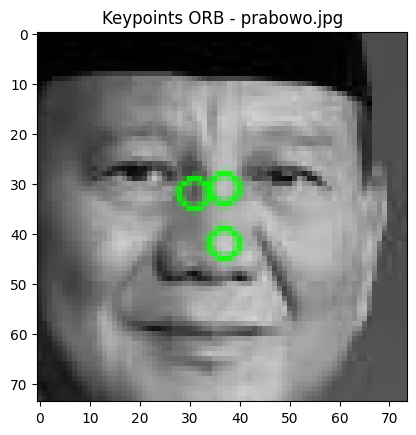

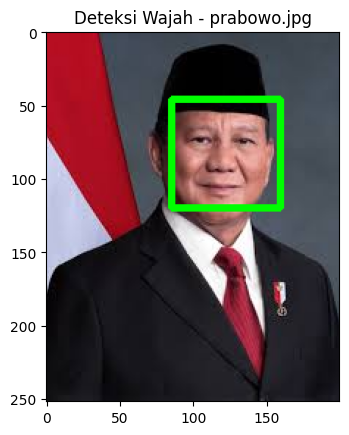

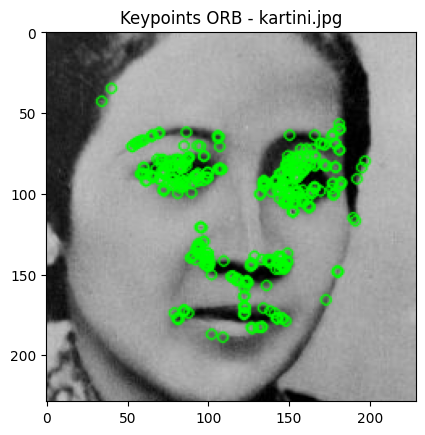

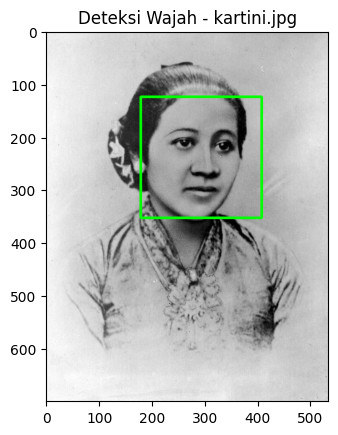

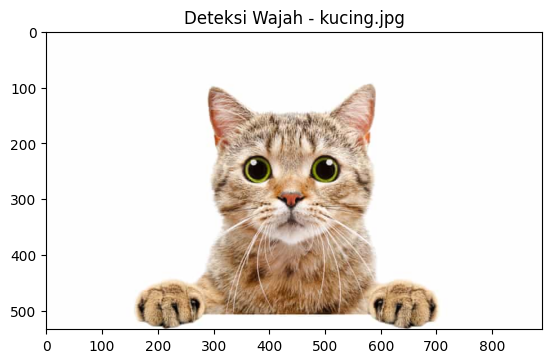

Error: Could not load image from /content/drive/MyDrive/Images/facedet/mask.jpg


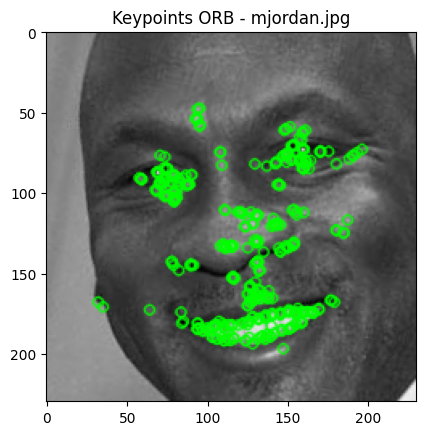

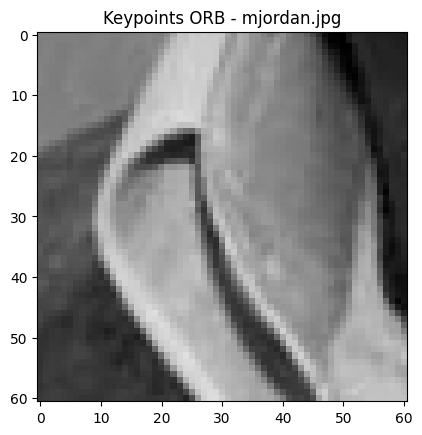

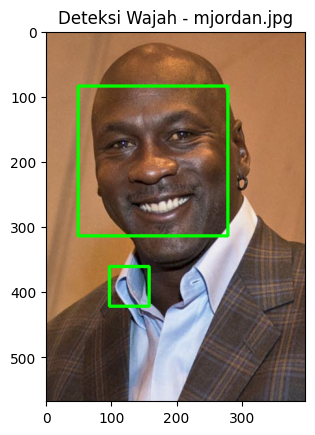

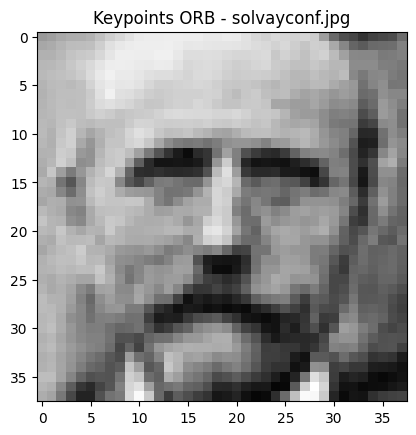

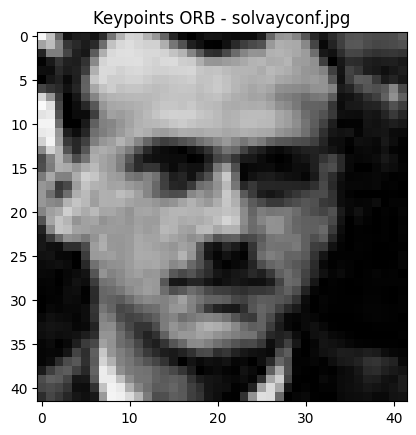

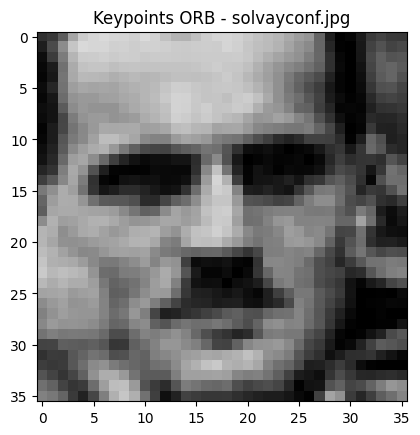

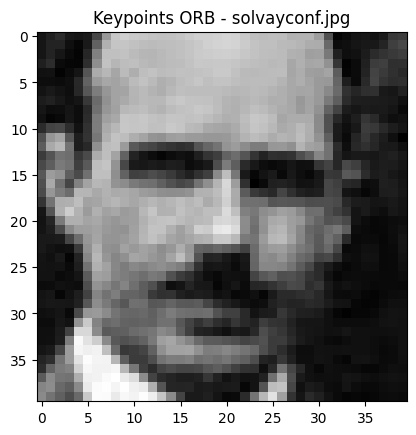

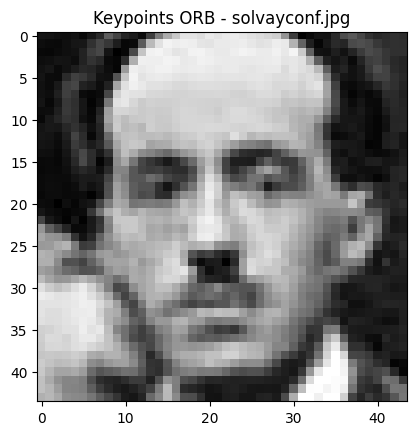

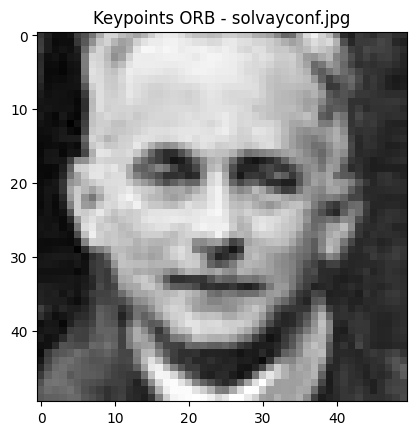

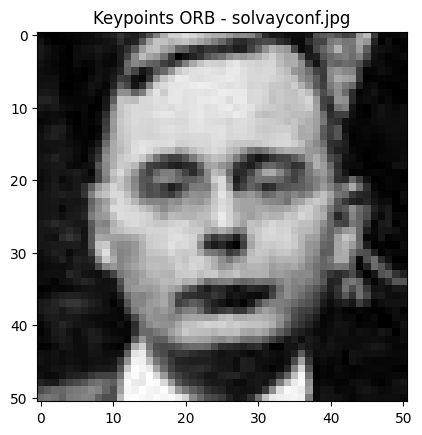

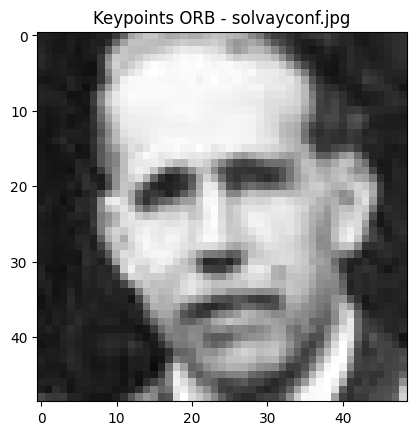

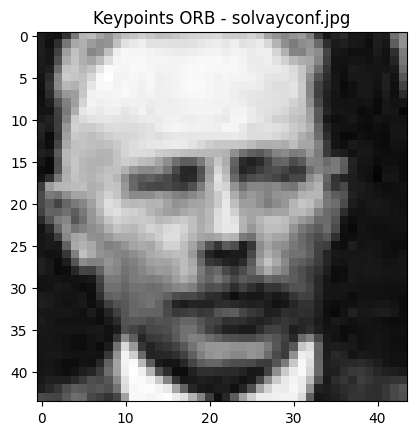

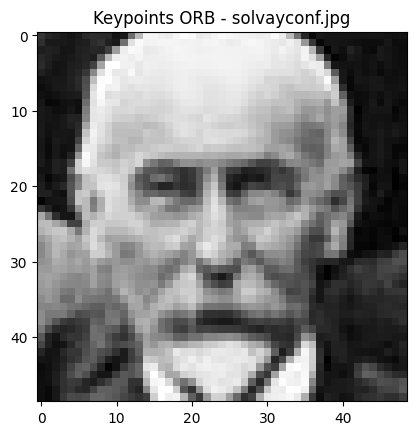

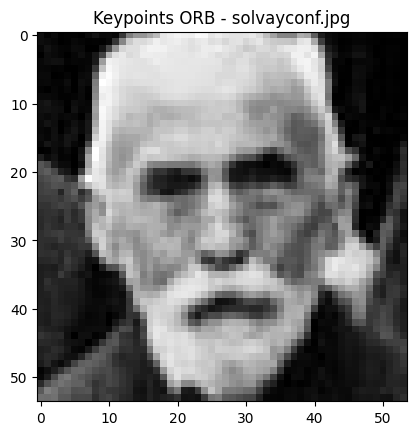

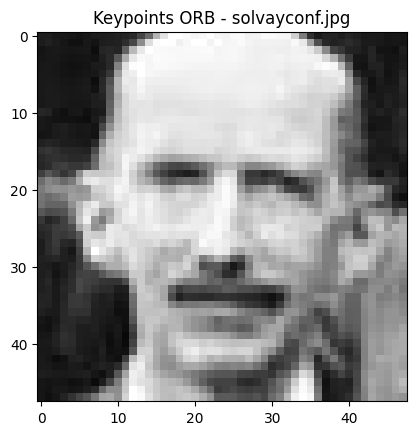

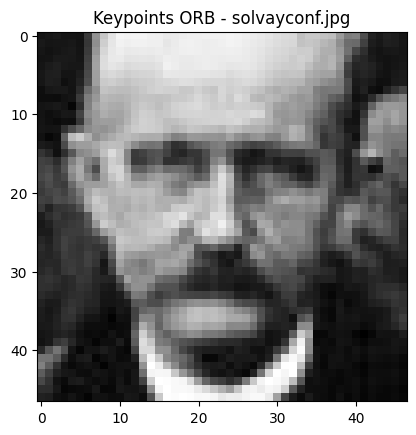

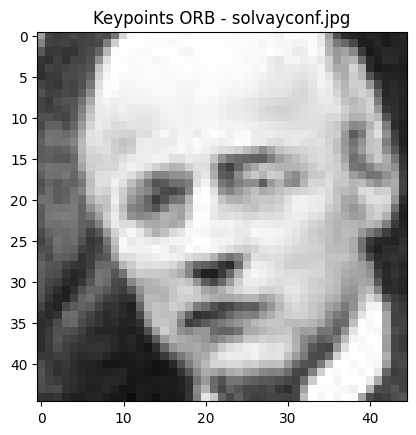

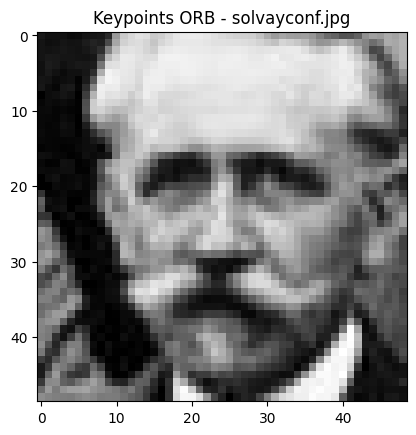

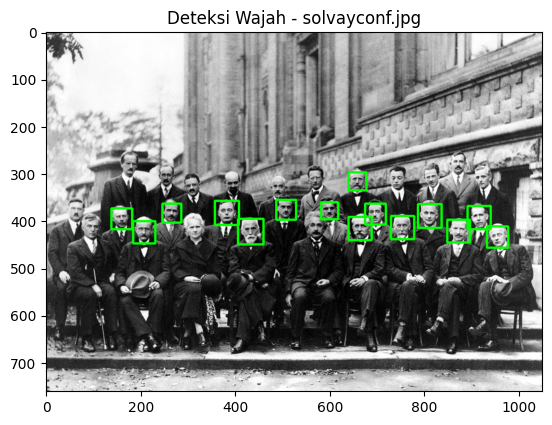

In [16]:
images = [
    '/content/drive/MyDrive/Images/prabowo.jpg',
    '/content/drive/MyDrive/Images/facedet/kartini.jpg',
    '/content/drive/MyDrive/Images/facedet/kucing.jpg',
    '/content/drive/MyDrive/Images/facedet/mask.jpg',
    '/content/drive/MyDrive/Images/facedet/mjordan.jpg',
    '/content/drive/MyDrive/Images/facedet/solvayconf.jpg'
]

# Load classifier wajah
face_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Inisialisasi ORB
orb = cv.ORB_create()

for path in images:
    img = cv.imread(path)
    if img is None:
        print(f"Error: Could not load image from {path}")
        continue

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Deteksi wajah
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    # Gambar kotak hijau di wajah
    for (x, y, w, h) in faces:
        cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 3)

        # Crop wajah untuk deteksi fitur ORB
        roi_gray = gray[y:y + h, x:x + w]
        # Check if roi_gray is empty before processing (e.g., if w or h is 0)
        if roi_gray.size == 0:
            print(f"Warning: ROI is empty for a detected face in {path}. Skipping ORB detection for this face.")
            continue

        kp, des = orb.detectAndCompute(roi_gray, None)

        # Gambar keypoints di wajah
        # Ensure face_with_kp is initialized and has correct dimensions for drawing keypoints
        # drawKeypoints expects an image to draw on, which should have the same type as roi_gray if drawing on it directly
        face_with_kp = cv.drawKeypoints(roi_gray, kp, None, color=(0, 255, 0), flags=0)
        plt.imshow(cv.cvtColor(face_with_kp, cv.COLOR_BGR2RGB))
        plt.title(f'Keypoints ORB - {path.split("/")[-1]}')
        plt.show()

    # Tampilkan hasil deteksi wajah
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(f'Deteksi Wajah - {path.split("/")[-1]}')
    plt.show()

Perhatikan pada hasil face detection diatas. Secara keseluruhan, face detection dapat
dilakukan dengan baik, bahkan untuk image berupa gambar bukan foto, wajah
bermasker, atau wajah yang berukuran kecil (solvay).


2. Pada Soal No.2. wajah kucing tidak bisa dideteksi dengan baik. Lakukan deteksi
wajah kucing hingga muncul rectangle pada bagian wajahnya. Petunjuk pada soal
ini, perhatikan pretrained features yang telah disediakan OpenCV. Gunakan xml
yang ada jika memang telah disediakan. Jika belum ada, coba cari dengan
searching melalui search engines.

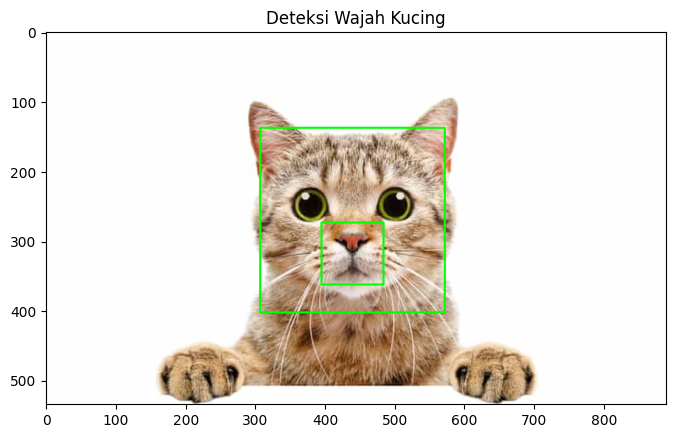

In [17]:
# Baca gambar kucing
img = cv.imread(kucing)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Load pretrained model untuk wajah kucing
cat_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_frontalcatface.xml')

# Deteksi wajah kucing
faces = cat_cascade.detectMultiScale(
    gray,
    scaleFactor=1.03,
    minNeighbors=3,
    minSize=(75, 75)
)

# Gambar rectangle di sekitar wajah kucing
for (x, y, w, h) in faces:
    cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Ubah format warna BGR -> RGB agar tampil benar di matplotlib
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Tampilkan hasil dengan Matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title('Deteksi Wajah Kucing')
plt.show()

3. Cobakan juga untuk eyes detection pada wajah Pak Prabowo:

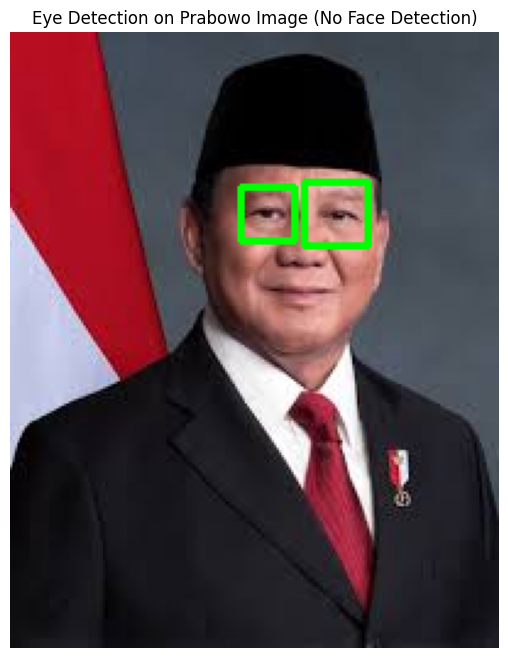

In [18]:

img_prabowo = cv.imread(prabs)
# Convert to grayscale
gray_prabowo = cv.cvtColor(img_prabowo, cv.COLOR_BGR2GRAY)

# Load the pre-trained eye cascade classifier
eye_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_eye.xml')

img_prabowo_detected = img_prabowo.copy()

# Detect eyes directly in the image
eyes = eye_cascade.detectMultiScale(gray_prabowo, 1.1, 5) # Adjust parameters as needed

# Draw rectangles around the eyes
for (ex, ey, ew, eh) in eyes:
    cv.rectangle(img_prabowo_detected, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2) # Green for eyes

# Display the result
plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(img_prabowo_detected, cv.COLOR_BGR2RGB))
plt.title('Eye Detection on Prabowo Image (No Face Detection)')
plt.axis('off')
plt.show()

4. Lakukan deteksi senyuman pada gambar people:


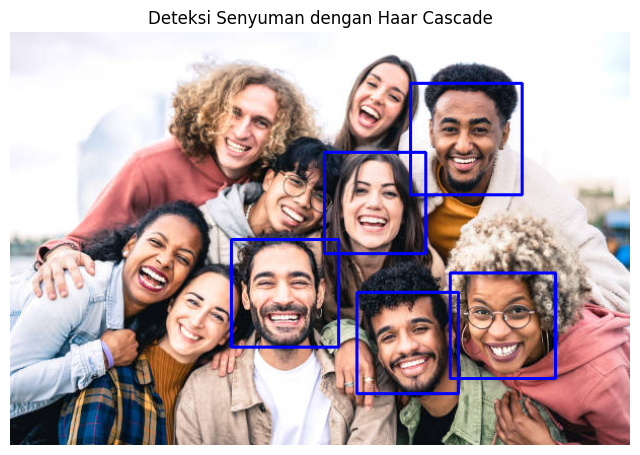

In [19]:
peeps = '/content/drive/MyDrive/citrapcvk/people.jpg'
img = cv.imread(peeps)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Load pretrained model wajah & senyum
face_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_frontalface_default.xml')
smile_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_smile.xml')

# Deteksi wajah terlebih dahulu
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=1, minSize=(100, 100))

for (x, y, w, h) in faces:
    # Gambar kotak pada wajah
    cv.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    # Area wajah untuk deteksi senyuman
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]

    # Deteksi senyuman di dalam area wajah
    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.7,   # nilai lebih tinggi = deteksi lebih selektif
        minNeighbors=22,   # naikkan jika banyak false positive
        minSize=(25, 25)
    )

    for (sx, sy, sw, sh) in smiles:
        cv.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 255, 0), 2)

# Konversi warna untuk tampil di Matplotlib
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Tampilkan hasil
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Deteksi Senyuman dengan Haar Cascade')
plt.show()

Lakukan Face Tracking menggunakan Google Colab. Petunjuk, Tutorial
selengkapnya tentang akses kamera dan FaceDetection pada google colab dapat
dilihat di link berikut: https://www.youtube.com/watch?v=YjWh7QvVH60

In [27]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import PIL.Image



In [28]:
def js_to_image(js_reply):
    """Konversi data base64 dari webcam JS ke array OpenCV"""
    image_bytes = b64decode(js_reply.split(',')[1])
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    img = cv.imdecode(jpg_as_np, cv.IMREAD_COLOR)
    return img

def video_frame(label="Ambil Gambar"):
    """Fungsi JS untuk menampilkan video dan mengambil 1 frame"""
    js = Javascript('''
      async function capture(label) {
        const div = document.createElement('div');
        const captureButton = document.createElement('button');
        captureButton.textContent = label;
        div.appendChild(captureButton);

        const video = document.createElement('video');
        video.style.display = 'block';
        div.appendChild(video);
        document.body.appendChild(div);

        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        video.srcObject = stream;
        await video.play();

        // Tunggu tombol diklik
        await new Promise((resolve) => captureButton.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(track => track.stop());
        div.remove();
        return canvas.toDataURL('image/jpeg', 0.8);
      }
    ''')
    display(js)
    data = eval_js(f'capture("{label}")')
    return js_to_image(data)


<IPython.core.display.Javascript object>

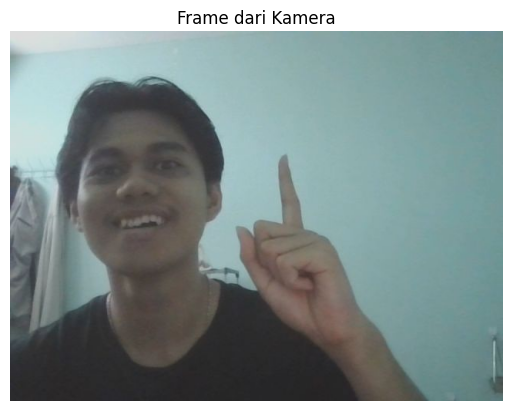

In [52]:
# Ambil satu frame dari kamera
img = video_frame("Ambil Gambar")
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Frame dari Kamera')
plt.show()


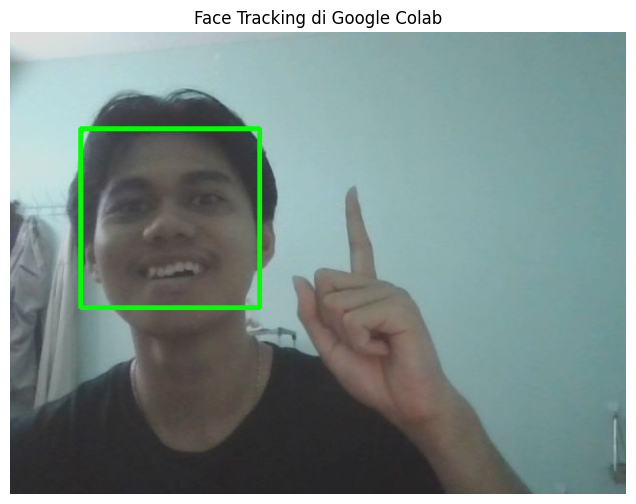

In [53]:
# Load Haar Cascade pretrained model untuk deteksi wajah
face_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Konversi ke grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Deteksi wajah
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# Gambar kotak di sekitar wajah
for (x, y, w, h) in faces:
    cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 3)

# Tampilkan hasil
plt.figure(figsize=(8,6))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Face Tracking di Google Colab')
plt.show()


6. Lakukan Blurring pada bagian wajah yang terdeteksi. Berikut contoh keluarannya.
Petunjuk: anda dapat menggunakan cv.medianBlur untuk melakukan Blurring


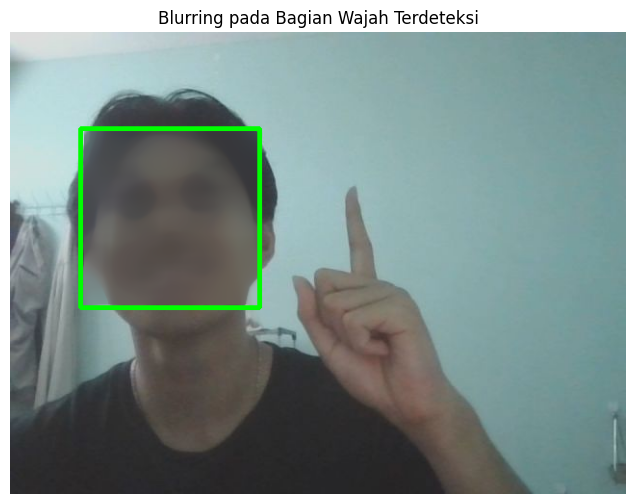

In [55]:
# Pastikan variabel img masih berisi frame dari kamera
# Jika belum, jalankan kembali fungsi video_frame() sebelumnya

# Load model deteksi wajah
face_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Konversi ke grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Deteksi wajah
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# Lakukan blurring pada setiap wajah yang terdeteksi
for (x, y, w, h) in faces:
    # Ambil area wajah
    face_roi = img[y:y+h, x:x+w]

    # Lakukan median blur pada area wajah
    blurred_face = cv.medianBlur(face_roi, 35)  # semakin besar nilainya, semakin blur

    # Ganti area wajah asli dengan hasil blur
    img[y:y+h, x:x+w] = blurred_face

# Konversi warna BGR -> RGB untuk ditampilkan dengan Matplotlib
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Tampilkan hasil
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Blurring pada Bagian Wajah Terdeteksi')
plt.show()

7. Mengolah gambar KTM masing-masing


a. Berikut ini contoh KTM

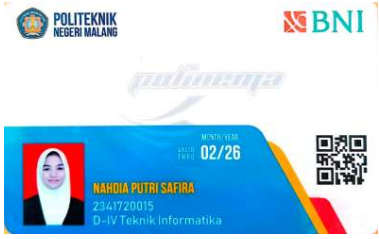

b. Tampilkan Foto KTM seperti contoh berikut ini:

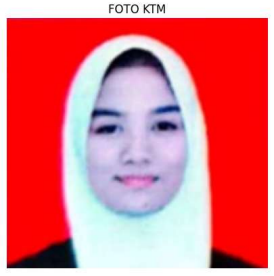

c. Lakukan Deteksi Obyek KTM pada gambar yang berisi KTM dengan
barang lainnya dengan menggunakan Konsep Feature Matching


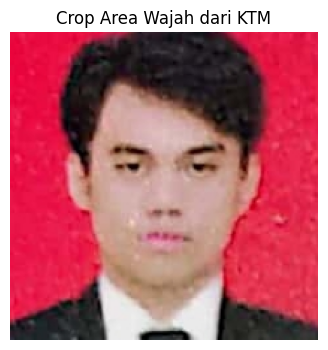

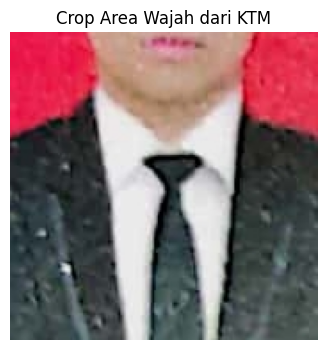

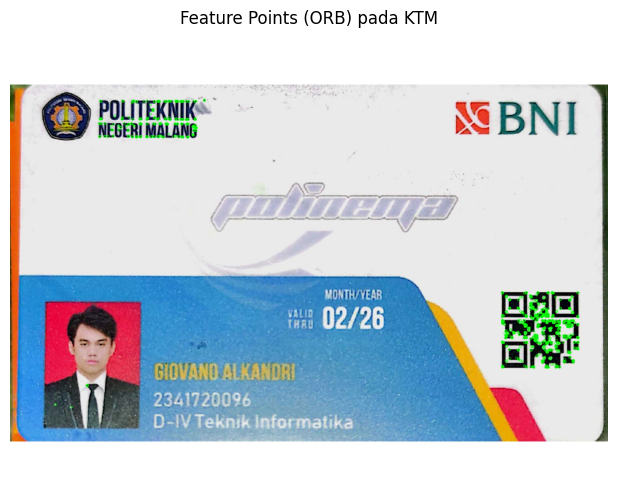

In [63]:
ktmku = ('/content/drive/MyDrive/citrapcvk/ktm.jpg')

# Baca gambar
img = cv.imread(ktmku)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# === 1. Deteksi fitur (optional, hanya untuk menunjukkan konsep feature matching) ===
orb = cv.ORB_create(nfeatures=1000)
keypoints, descriptors = orb.detectAndCompute(gray, None)
img_keypoints = cv.drawKeypoints(img, keypoints, None, color=(0,255,0), flags=0)

# === 2. Deteksi wajah menggunakan Haar Cascade ===
face_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(70,70))

# === 3. Jika wajah ditemukan, crop dengan padding ===
if len(faces) > 0:
    for (x, y, w, h) in faces:
        pad = 40  # padding tambahan
        x1 = max(x - pad, 0)
        y1 = max(y - pad, 0)
        x2 = min(x + w + pad, img.shape[1])
        y2 = min(y + h + pad, img.shape[0])
        face_crop = img[y1:y2, x1:x2]

        # Tampilkan hasil crop wajah
        plt.figure(figsize=(4,4))
        plt.imshow(cv.cvtColor(face_crop, cv.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('Crop Area Wajah dari KTM')
        plt.show()
else:
    print("Wajah tidak terdeteksi pada KTM.")

# === 4. (Opsional) Tampilkan fitur ORB untuk bukti konsep Feature Matching ===
plt.figure(figsize=(8,6))
plt.imshow(cv.cvtColor(img_keypoints, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Feature Points (ORB) pada KTM')
plt.show()

Tambahan Tugas Praktikum:
Tampilkan karakter-karakter pada KTM ini Deep Learning untuk melakukan
pengenalan karakter. Sebelum melakukan training data, terlebih dahulu di
siapkan data yang akan dilakukan training yaitu data image nomor angka 0-9.
Untuk membuat data tersebut bisa gunakan image editor untuk dilakukan croping
satu persatu. Kemudian selanjutnya gunakan source code di bawah ini untuk
proses persiapan untuk training.

In [73]:
import os
import tqdm
import random
import numpy as np
import pickle
# Direktori data training
DATADIR = "/content/drive/MyDrive/citrapcvk/dataset_angka/"
dirs = []

training_data = []
width, height = 100, 100

# Looping direktori data training untuk diambil nama karakternya
for char_name in sorted(os.listdir(DATADIR)):
  dirs.append(char_name)

# Looping semua image data training untuk diubah menjadi array
for char_name in dirs:
  path = os.path.join(DATADIR, char_name)
  class_number = dirs.index(char_name)
  for img in tqdm.tqdm(os.listdir(path)):
      try:
        img_array = cv.imread(os.path.join(data_dir_testing, car, char_image), cv.IMREAD_ANYCOLOR)
        new_array = cv.resize(img_array, (width, height))
        training_data.append([new_array, class_number])
      except Exception as e:
        pass

random.shuffle(training_data)
X = []
Y = []

for feature, label in training_data:
  X.append(feature)
  Y.append(label)

X = np.array(X).reshape(-1, width, height, 1)

# Tulis ke file pickle
pickle_out = open("X.pickle", "wb")
pickle.dump(X, pickle_out)
pickle_out.close()

pickle_out = open("Y.pickle", "wb")
pickle.dump(Y, pickle_out)
pickle_out.close()

100%|██████████| 100/100 [00:00<00:00, 342671.90it/s]


Penjelasan kode di atas adalah sebagai berikut ini

i. Import terlebih dahulu beberapa yang paket-paket yang dibutuhkan,
ada beberapa paket yang baru misalkan tqdm digunakan untuk
meload data diikuti dengan progress bar, numpy merupakan sebuah
paket yang digunakan untuk melakukan operasi-operasi matriks atau array serta pickle adalah depedensi untuk menyimpan file untuk
model data training.

ii. Looping data training yang kelak digunakan untuk melabeli hasil
pengenalan. Looping semua file training untuk diubah ke dalam
sebuah image array.

iii. Variabel X dan variabel Y digunakan untuk menyimpan label dan
feature, label berisi karakter A-Z dan 0-9 sedangkan feture berisi
data image array masing-masing label tersebut.

iv. Terakhir tulis isi variabel X dan variabel Y ke dalam sebuah file
pickle. File pickle tersebut nanti akan diload ketika proses training
data.

Lakukan Training Data

Code berikut digunakan untuk melakukan training data

In [70]:
!pip install tensorflow

In [78]:
import os
import pickle
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, ZeroPadding2D
from keras.models import Model
from keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# === [1] SETUP DATASET ===
# Ganti path sesuai folder dataset kamu di Google Drive
# Misal struktur folder:
# /content/drive/MyDrive/dataset/
# ├── A/
# ├── B/
# ├── C/
dataset_path = '/content/drive/MyDrive/citrapcvk/dataset_angka/'
width, height = 100, 100

X = []
Y = []

categories = os.listdir(dataset_path)
print("Kategori terdeteksi:", categories)

for category in categories:
    category_path = os.path.join(dataset_path, category)
    label = categories.index(category)  # label numerik dari folder
    for file in os.listdir(category_path):
        try:
            img_path = os.path.join(category_path, file)
            img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
            img = cv.resize(img, (width, height))
            X.append(img)
            Y.append(label)
        except Exception as e:
            print("Gagal membaca:", file, "error:", e)

X = np.array(X).reshape(-1, width, height, 1)
Y = np.array(Y)

# === [2] SIMPAN PAKAI PICKLE ===
with open('X.pickle', 'wb') as f:
    pickle.dump(X, f)
with open('Y.pickle', 'wb') as f:
    pickle.dump(Y, f)

print(f"Dataset tersimpan: {X.shape}, Label: {Y.shape}")

# === [3] NORMALISASI & KATEGORIKAL ===
X = X / 255.0
Y = to_categorical(Y)
num_classes = Y.shape[1]

# === [4] BANGUN MODEL CNN ===
inputs = Input(shape=(width, height, 1))
conv_layer = ZeroPadding2D(padding=(2, 2))(inputs)
conv_layer = Conv2D(16, (5, 5), activation='relu')(conv_layer)
conv_layer = MaxPooling2D((2, 2))(conv_layer)
conv_layer = Conv2D(32, (3, 3), activation='relu')(conv_layer)
conv_layer = Conv2D(32, (3, 3), activation='relu')(conv_layer)
conv_layer = MaxPooling2D((2, 2))(conv_layer)
conv_layer = Conv2D(64, (3, 3), activation='relu')(conv_layer)
flaten = Flatten()(conv_layer)
fc_layer = Dense(256, activation='relu')(flaten)
fc_layer = Dense(64, activation='relu')(fc_layer)
outputs = Dense(num_classes, activation='softmax')(fc_layer)

adam = Adam(learning_rate=0.0001)
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

# === [5] TRAIN MODEL ===
model.fit(X, Y, epochs=10, verbose=1, validation_split=0.2)

# === [6] SIMPAN MODEL ===
model.save('/content/drive/MyDrive/citrapcvk/anpr.keras')
print("Model tersimpan di Google Drive sebagai 'anpr.keras'")


Kategori terdeteksi: ['2', '8', '6', '9', '4', '7', '1', '3', '5', '0']
Dataset tersimpan: (1000, 100, 100, 1), Label: (1000,)
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 627ms/step - accuracy: 0.1851 - loss: 2.1475 - val_accuracy: 0.0000e+00 - val_loss: 4.9102
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 636ms/step - accuracy: 0.9380 - loss: 0.9261 - val_accuracy: 0.0000e+00 - val_loss: 14.2343
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 583ms/step - accuracy: 0.9950 - loss: 0.0980 - val_accuracy: 0.0000e+00 - val_loss: 21.0530
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 564ms/step - accuracy: 0.9953 - loss: 0.0265 - val_accuracy: 0.0000e+00 - val_loss: 24.7503
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 586ms/step - accuracy: 1.0000 - loss: 0.0110 - val_accuracy: 0.0000e+00 - val_loss: 26.1434
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 583ms/step - accuracy: 0.9972 - loss: 0.0123 - val_accuracy: 0.0000e+00 - val_loss: 26.9561
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 589ms/step - accuracy: 1.000

In [79]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

# === [1] Path dataset utama ===
data_dir = "/content/drive/MyDrive/citrapcvk/dataset_angka"   # ganti sesuai lokasi dataset kamu
width, height = 100, 100

# === [2] Siapkan data dan label ===
X = []
Y = []
dirs = sorted(os.listdir(data_dir))

print("Kategori terdeteksi:", dirs)

for label, char_name in enumerate(dirs):
    char_path = os.path.join(data_dir, char_name)
    for img_file in os.listdir(char_path):
        try:
            img = cv.imread(os.path.join(char_path, img_file), cv.IMREAD_GRAYSCALE)
            img = cv.resize(img, (width, height))
            X.append(img)
            Y.append(label)
        except Exception as e:
            print(f"Gagal membaca {img_file}:", e)

X = np.array(X).reshape(-1, width, height, 1)
Y = np.array(Y)
X = X / 255.0

print("Total data:", len(X))
print("Total label:", len(Y))

# === [3] Split data (80% train, 20% test) ===
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print(f"Data training: {len(X_train)}, Data testing: {len(X_test)}")

# === [4] Load model ===
model = tf.keras.models.load_model("/content/drive/MyDrive/citrapcvk/anpr.keras")

# === [5] Evaluasi model ===
loss, acc = model.evaluate(X_test, tf.keras.utils.to_categorical(Y_test), verbose=0)
print(f"Akurasi pada data test: {acc*100:.2f}%")

# === [6] Prediksi dan tampilkan hasil untuk contoh testing ===
print("\nContoh hasil prediksi:")
for i in range(5):  # tampilkan 5 contoh acak
    pred = model.predict(X_test[i].reshape(1, width, height, 1))
    actual = dirs[Y_test[i]]
    predicted = dirs[np.argmax(pred[0])]
    print(f"Data {i+1}: Asli = {actual}, Prediksi = {predicted}")

Kategori terdeteksi: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Total data: 1000
Total label: 1000
Data training: 800, Data testing: 200
Akurasi pada data test: 10.00%

Contoh hasil prediksi:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Data 1: Asli = 1, Prediksi = 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Data 2: Asli = 0, Prediksi = 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Data 3: Asli = 6, Prediksi = 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Data 4: Asli = 5, Prediksi = 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Data 5: Asli = 0, Prediksi = 3
